# Combined Step 8 + Step 9 (Colab Ready)

This notebook combines:
- **Step 8**: Gymnasium multi-case environment
- **Step 9**: MaskablePPO training + evaluation

Run cells top-to-bottom in Colab.
- Preferred: place `output.zip` in your Google Drive and let Cell 3 load it automatically.
- Optional: place `output.zip` directly in the Colab working directory (`/content`).

In [1]:
%pip install -q gymnasium stable-baselines3 sb3-contrib pyarrow pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 7.3 MB/s eta 0:00:00


In [2]:
import json
import time
import zipfile
import shutil
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from collections import defaultdict
from typing import List

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks

ROOT = Path('.')
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ZIP_PATH = ROOT / 'output.zip'

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Set this once if your zip is in Google Drive.
# Example (your current setup): '/content/drive/MyDrive/output.zip'
DRIVE_ZIP_PATH = Path('/content/drive/MyDrive/output.zip')

def _extract_output_zip(zip_path: Path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = [n for n in zf.namelist() if n and not n.endswith('/')]
        has_output_prefix = any(n.startswith('output/') for n in names)
        if has_output_prefix:
            zf.extractall(ROOT)
        else:
            zf.extractall(OUTPUT_DIR)

if IN_COLAB:
    selected_zip = OUTPUT_ZIP_PATH if OUTPUT_ZIP_PATH.exists() else None

    if selected_zip is None:
        # drive_zip_candidates = [
        #     DRIVE_ZIP_PATH,
        #     Path('/content/drive/MyDrive/output.zip'),
        #     Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer/output.zip'),
        #     Path('/content/drive/MyDrive/bureaucratic_workflow_analyzer/output.zip'),
        #     Path('/content/drive/MyDrive/bureaucratic_workflow_checkpoints/output.zip'),
        # ]
        try:
            from google.colab import drive  # type: ignore
            drive.mount('/content/drive', force_remount=False)
            selected_zip = DRIVE_ZIP_PATH if DRIVE_ZIP_PATH.exists() else None
            # for cand in drive_zip_candidates:
            #     if cand.exists():
            #         selected_zip = cand
            #         break
        except Exception as exc:
            print(f'Google Drive mount failed: {exc}')

    if selected_zip is None:
        raise FileNotFoundError(
            'Could not find output.zip. Place it either at /content/output.zip '
            'or in Google Drive (e.g., /content/drive/MyDrive/output.zip), then re-run this cell.'
        )

    if selected_zip.resolve() != OUTPUT_ZIP_PATH.resolve():
        shutil.copy2(selected_zip, OUTPUT_ZIP_PATH)
        print(f'Copied zip from Drive to runtime: {selected_zip} -> {OUTPUT_ZIP_PATH}')
    else:
        print(f'Using runtime zip: {OUTPUT_ZIP_PATH}')

    _extract_output_zip(OUTPUT_ZIP_PATH)
    print(f'Output dir: {OUTPUT_DIR.resolve()}')
else:
    print('Not in Colab: skipping zip extraction. Expecting local ./output artifacts.')

required = [
    'case_step_features.parquet',
    'graph_priors.json',
    'transition_stats.csv',
    'duration_stats.csv',
    'valid_action_space.csv',
    'sim_calibration.json',
    'resource_calibration.json',
    'reward_params_kpi_tuned.json',
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing required files in ./output: {missing}')
print('All required artifacts found.')

Mounted at /content/drive
Copied zip from Drive to runtime: /content/drive/MyDrive/output.zip -> output.zip
Output dir: /content/output
All required artifacts found.


In [3]:
FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
GRAPH_PRIORS_PATH = OUTPUT_DIR / 'graph_priors.json'
TRANSITION_STATS_PATH = OUTPUT_DIR / 'transition_stats.csv'
DURATION_STATS_PATH = OUTPUT_DIR / 'duration_stats.csv'
ACTION_SPACE_PATH = OUTPUT_DIR / 'valid_action_space.csv'
CALIBRATION_PATH = OUTPUT_DIR / 'sim_calibration.json'
TUNED_REWARD_PATH = OUTPUT_DIR / 'reward_params_kpi_tuned.json'
RESOURCE_CALIBRATION_PATH = OUTPUT_DIR / 'resource_calibration.json'

features_df = pd.read_parquet(FEATURES_PARQUET)
with open(GRAPH_PRIORS_PATH) as f:
    graph_priors = json.load(f)
transitions_df = pd.read_csv(TRANSITION_STATS_PATH)
durations_df = pd.read_csv(DURATION_STATS_PATH)
actions_df = pd.read_csv(ACTION_SPACE_PATH)

ACTION_MAP = dict(zip(actions_df['action_id'], actions_df['action_name']))
ACTION_NAME_TO_IDX = {v: k for k, v in ACTION_MAP.items()}
NUM_ACTIONS = len(ACTION_MAP)

with open(CALIBRATION_PATH) as f:
    calibration = json.load(f)
with open(TUNED_REWARD_PATH) as f:
    reward_tuning = json.load(f)
reward_params = reward_tuning.get('tuned_params', {'alpha': 0.02, 'beta': 0.75, 'delta': 2.5, 'gamma': 12.0})
with open(RESOURCE_CALIBRATION_PATH) as f:
    resource_config = json.load(f)

unique_activities = sorted(features_df['activity'].dropna().unique())
ACTIVITY_ENCODER = {act: idx for idx, act in enumerate(unique_activities)}
ACTIVITY_DECODER = {idx: act for act, idx in ACTIVITY_ENCODER.items()}

def build_transition_lookup():
    lookup = defaultdict(dict)
    for _, row in transitions_df.iterrows():
        src = str(row['activity'])
        tgt = str(row['next_activity'])
        prob = float(row['transition_prob'])
        lookup[src][tgt] = prob
    return dict(lookup)

def build_duration_lookup():
    lookup = {}
    for _, row in durations_df.iterrows():
        act = str(row['activity'])
        try:
            m = int(row['municipality'])
        except (ValueError, TypeError):
            continue
        lookup[(act, m)] = float(row['duration_median_hours'])
    return lookup

transition_lookup = build_transition_lookup()
duration_lookup = build_duration_lookup()
print(f'Loaded artifacts. Activities={len(unique_activities)}, actions={NUM_ACTIONS}, transitions={len(transition_lookup)}')

Loaded artifacts. Activities=356, actions=15, transitions=355


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
@dataclass
class Case:
    case_id: str
    municipality: int
    arrival_time: float
    current_activity: str = 'START'
    prev_activity: str = 'START'
    time_at_current: float = 0.0
    total_time: float = 0.0
    predicted_trace_length: int = 20
    step_index: int = 0
    rework_count: int = 0
    branch_label: str = 'unknown'
    branch_confidence: float = 0.5
    is_completed: bool = False
    completed_time: float = -1.0
    priority: float = 0.0

    def progress(self) -> float:
        return self.step_index / max(self.predicted_trace_length, 1)

class BPICMultiCaseEnv(gym.Env):
    def __init__(self, municipality=1, seed=None, max_episode_hours=168, resource_config=None):
        super().__init__()
        self.municipality = municipality
        self.max_episode_hours = max_episode_hours
        self.arrival_rate = 2.0
        self.np_random = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

        if resource_config and isinstance(resource_config, dict):
            by_m = resource_config.get('by_municipality', {})
            m_cfg = by_m.get(str(municipality)) or by_m.get(municipality)
            if m_cfg:
                self.min_workers = int(m_cfg.get('min_workers', 5))
                self.initial_workers = int(m_cfg.get('initial_workers', 6))
                self.max_workers = int(m_cfg.get('max_workers', 9))
            else:
                self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9
        else:
            self.min_workers, self.initial_workers, self.max_workers = 5, 6, 9

        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.duration_cap_hours = 8.0
        self.sim_time_scaling = 1.0
        self.reward_mode = 'kpi_tuned'
        self.reward_params = {
            'alpha': float(reward_params.get('alpha', 0.02)),
            'beta': float(reward_params.get('beta', 0.75)),
            'delta': float(reward_params.get('delta', 2.50)),
            'gamma': max(float(reward_params.get('gamma', 12.00)), 40.0),
        }
        self.sla_breached_case_ids = set()

        start_like = [a for a in transition_lookup.keys() if isinstance(a, str) and a.lower().startswith('start ')]
        self.start_activity_candidates = start_like if start_like else ['START']

        self.metadata = {'render_modes': ['human']}
        self.action_space = gym.spaces.Discrete(15)
        self.observation_space = gym.spaces.Dict({
            'queue_lengths': gym.spaces.Box(0, 1000, shape=(15,), dtype=np.int32),
            'active_case_ages': spaces.Box(0, 500, shape=(100,), dtype=np.float32),
            'available_workers': gym.spaces.Box(self.min_workers, self.max_workers, shape=(), dtype=np.int32),
            'current_hour': gym.spaces.Box(0, 500, shape=(), dtype=np.float32)
        })

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.np_random = np.random.default_rng(seed)
        self.active_cases = []
        self.total_workers = self.initial_workers
        self.current_time = 0.0
        self.completed_cases = []
        self.case_counter = 0
        self.sla_breached_case_ids = set()
        return self._get_obs(), {}

    def action_masks(self):
        mask = [1] * 15
        if self.total_workers >= self.max_workers:
            for a in [0, 1, 8, 9, 12]:
                mask[a] = 0
        if self.total_workers <= self.min_workers:
            mask[11] = 0
        if self.active_cases:
            if max(c.progress() for c in self.active_cases) < 0.3:
                mask[14] = 0
        else:
            mask[14] = 0
        return np.array(mask, dtype=np.int8)

    def step(self, action):
        if isinstance(action, np.ndarray):
            action = int(np.asarray(action).reshape(-1)[0])
        else:
            action = int(action)

        self.current_time += 1.0
        num_arrivals = self.np_random.poisson(self.arrival_rate / 24.0)
        for _ in range(num_arrivals):
            case = Case(
                case_id=f'case_{self.case_counter}',
                municipality=self.municipality,
                arrival_time=self.current_time,
                current_activity=self._sample_initial_activity(),
                predicted_trace_length=20,
            )
            self.case_counter += 1
            self.active_cases.append(case)

        if action == 0 and len(self.active_cases) > 4 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 1 and len(self.active_cases) > 6 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 8 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            max_age = max([self.current_time - c.arrival_time for c in self.active_cases]) if self.active_cases else 0
            if max_age > 10.0:
                self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 9 and len(self.active_cases) > 5 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)
        elif action == 11 and self.total_workers > self.min_workers and len(self.active_cases) < 3:
            self.total_workers = max(self.min_workers, self.total_workers - 1)
        elif action == 12 and len(self.active_cases) > 8 and self.total_workers < self.max_workers:
            self.total_workers = min(self.max_workers, self.total_workers + 1)

        completed_this_step = 0
        if self.active_cases and self.total_workers > 0:
            prioritized = self._prioritize_cases(action)
            allocation = self._allocate_workers(action, len(prioritized))
            remaining = []

            for idx, case in enumerate(prioritized):
                curr = case.current_activity
                if curr == 'END':
                    case.total_time = self.current_time - case.arrival_time
                    case.completed_time = self.current_time
                    case.is_completed = True
                    self.completed_cases.append(case)
                    completed_this_step += 1
                    continue

                workers_for_case = allocation[idx] if idx < len(allocation) else 0
                if workers_for_case <= 0:
                    remaining.append(case)
                    continue

                duration = duration_lookup.get((curr, self.municipality), 1.0)
                effective_duration = max(2.0, min(duration, self.duration_cap_hours))
                frac = workers_for_case / (effective_duration * self._get_time_scaling(action))
                case.time_at_current += frac
                case.total_time += 1.0

                if case.time_at_current >= 1.0:
                    case.step_index += 1
                    case.prev_activity = case.current_activity
                    if case.step_index >= case.predicted_trace_length:
                        next_act = 'END'
                    elif curr in transition_lookup:
                        next_act = self.np_random.choice(list(transition_lookup[curr].keys()), p=list(transition_lookup[curr].values()))
                    else:
                        next_act = 'END'

                    case.current_activity = next_act
                    case.time_at_current = 0.0
                    if case.current_activity == 'END':
                        case.total_time = self.current_time - case.arrival_time
                        case.completed_time = self.current_time
                        case.is_completed = True
                        self.completed_cases.append(case)
                        completed_this_step += 1
                    else:
                        remaining.append(case)
                else:
                    remaining.append(case)

            self.active_cases = remaining

        completion_reward, queue_penalty, sla_penalty, action_bonus, reward = self._compute_reward(action, completed_this_step)
        obs = self._get_obs()
        truncated = self.current_time >= self.max_episode_hours
        info = {
            'queue_length': len(self.active_cases),
            'total_workers': self.total_workers,
            'completed_cases': len(self.completed_cases),
            'reward_mode': self.reward_mode,
            'reward_components': {
                'completion': completion_reward,
                'queue_penalty': queue_penalty,
                'sla_penalty': sla_penalty,
                'action_bonus': action_bonus,
                'reward_total': reward,
            },
        }
        return obs, reward, False, truncated, info

    def _compute_reward(self, action, completed_this_step):
        alpha = self.reward_params['alpha']
        beta = self.reward_params['beta']
        delta = self.reward_params['delta']
        gamma = self.reward_params['gamma']
        completion_reward = beta * float(completed_this_step)
        queue_penalty = -alpha * float(len(self.active_cases))

        active_ids = {c.case_id for c in self.active_cases}
        self.sla_breached_case_ids.intersection_update(active_ids)
        new_breaches = 0
        for c in self.active_cases:
            if (self.current_time - c.arrival_time) > gamma and c.case_id not in self.sla_breached_case_ids:
                self.sla_breached_case_ids.add(c.case_id)
                new_breaches += 1
        sla_penalty = -delta * float(new_breaches)
        action_bonus = 0.0
        reward = completion_reward + queue_penalty + sla_penalty
        return completion_reward, queue_penalty, sla_penalty, action_bonus, reward

    def _sample_initial_activity(self):
        if not self.start_activity_candidates:
            return 'START'
        idx = int(self.np_random.integers(0, len(self.start_activity_candidates)))
        return self.start_activity_candidates[idx]

    def _allocate_workers(self, action, num_cases):
        if num_cases == 0:
            return []
        total = self.total_workers

        if action == 0:
            if num_cases == 1:
                return [total]
            first = min(int(total * 0.6), total)
            rem = total - first
            per_case = rem // (num_cases - 1)
            extra = rem % (num_cases - 1)
            alloc = [first] + [per_case + (1 if i < extra else 0) for i in range(num_cases - 1)]
        elif action == 4:
            if num_cases == 1:
                return [total]
            first = min(int(total * 0.8), total)
            rem = total - first
            per_case = rem // (num_cases - 1)
            extra = rem % (num_cases - 1)
            alloc = [first] + [per_case + (1 if i < extra else 0) for i in range(num_cases - 1)]
        elif action == 5:
            to_dist = max(0, int(total * 0.4))
            per_case = to_dist // num_cases
            extra = to_dist % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]
        elif action in [7, 11]:
            to_dist = max(0, int(total * 0.5))
            per_case = to_dist // num_cases
            extra = to_dist % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]
        else:
            per_case = total // num_cases
            extra = total % num_cases
            alloc = [per_case + (1 if i < extra else 0) for i in range(num_cases)]

        assert sum(alloc) <= total
        return alloc

    def _get_time_scaling(self, action):
        action_scaling = {3: 3.5, 5: 7.0, 0: 4.0, 4: 4.5, 7: 5.5, 13: 6.0}
        return action_scaling.get(action, self.sim_time_scaling)

    def _get_obs(self):
        queue_by_activity = [0] * 15
        for case in self.active_cases:
            act_idx = min(ACTIVITY_ENCODER.get(case.current_activity, 0), 14)
            queue_by_activity[act_idx] += 1

        case_ages = np.array([self.current_time - c.arrival_time for c in self.active_cases][:100], dtype=np.float32)
        padded = np.zeros(100, dtype=np.float32)
        padded[:len(case_ages)] = case_ages

        return {
            'queue_lengths': np.array(queue_by_activity, dtype=np.int32),
            'active_case_ages': padded,
            'available_workers': np.array(self.total_workers, dtype=np.int32),
            'current_hour': np.array(self.current_time, dtype=np.float32),
        }

    def _prioritize_cases(self, action):
        if action == 2:
            return sorted(self.active_cases, key=lambda c: c.arrival_time)
        if action == 4:
            return [self.active_cases[0]] + sorted(self.active_cases[1:], key=lambda c: c.arrival_time) if self.active_cases else []
        if action == 5:
            return sorted(self.active_cases, key=lambda c: c.arrival_time, reverse=True)
        if action == 6:
            return sorted(self.active_cases, key=lambda c: c.step_index, reverse=True)
        if action == 7:
            return sorted(self.active_cases, key=lambda c: duration_lookup.get((c.current_activity, self.municipality), 5.0))
        if action == 10:
            return self.active_cases[::2] + self.active_cases[1::2]
        if action == 13:
            return sorted(self.active_cases, key=lambda c: duration_lookup.get((c.current_activity, self.municipality), 5.0), reverse=True)
        if action == 14:
            return sorted(self.active_cases, key=lambda c: c.step_index, reverse=True)
        return self.active_cases

print('Environment class ready.')

Environment class ready.


In [5]:
class DictScalarToVectorObsWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_space = env.observation_space
        if not isinstance(old_space, gym.spaces.Dict):
            raise TypeError('Expected Dict observation space')

        self.scalar_keys = []
        new_spaces = {}
        for key, space in old_space.spaces.items():
            if isinstance(space, gym.spaces.Box) and space.shape == ():
                low = np.array([space.low], dtype=space.dtype)
                high = np.array([space.high], dtype=space.dtype)
                new_spaces[key] = gym.spaces.Box(low=low, high=high, shape=(1,), dtype=space.dtype)
                self.scalar_keys.append(key)
            else:
                new_spaces[key] = space
        self.observation_space = gym.spaces.Dict(new_spaces)

    def observation(self, observation):
        obs = dict(observation)
        for key in self.scalar_keys:
            obs[key] = np.asarray(obs[key], dtype=self.observation_space[key].dtype).reshape(1,)
        return obs

    def action_masks(self):
        return self.env.action_masks()

class RewardBonusScaleWrapper(gym.Wrapper):
    def __init__(self, env, bonus_scale: float = 1.0):
        super().__init__(env)
        self.bonus_scale = float(bonus_scale)

    def action_masks(self):
        return self.env.action_masks()

    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        rc = info.get('reward_components', {}) if isinstance(info, dict) else {}
        if isinstance(rc, dict):
            original_bonus = float(rc.get('action_bonus', 0.0))
            scaled_bonus = original_bonus * self.bonus_scale
            reward = float(reward) - original_bonus + scaled_bonus
            rc['action_bonus_original'] = original_bonus
            rc['action_bonus'] = scaled_bonus
            info['reward_components'] = rc
        return obs, reward, done, truncated, info

def action_mask_fn(env):
    return env.action_masks()

def make_masked_env(municipality: int, seed: int, arrival_rate: float, max_episode_hours: int = 168, bonus_scale: float = 1.0):
    env = BPICMultiCaseEnv(municipality=municipality, seed=seed, max_episode_hours=max_episode_hours, resource_config=resource_config)
    env.arrival_rate = arrival_rate
    env.reward_mode = 'kpi_tuned'
    env.sim_time_scaling = 1.0
    env.reward_params['gamma'] = max(float(env.reward_params.get('gamma', 12.0)), 40.0)
    env = RewardBonusScaleWrapper(env, bonus_scale=bonus_scale)
    env = DictScalarToVectorObsWrapper(env)
    return ActionMasker(env, action_mask_fn)

def make_vec_env(municipalities: List[int], seed: int, arrival_rate: float, bonus_scale: float = 1.0):
    env_fns = []
    for i, m in enumerate(municipalities):
        local_seed = seed + i * 17
        env_fns.append(lambda m=m, s=local_seed: make_masked_env(m, s, arrival_rate, bonus_scale=bonus_scale))
    return DummyVecEnv(env_fns)

env_check = make_masked_env(municipality=1, seed=42, arrival_rate=2.0, bonus_scale=0.0)
obs, _ = env_check.reset()
mask = env_check.action_masks()
print('Mask length:', len(mask), 'Valid actions:', int(mask.sum()))
print('Obs shapes:', {k: np.asarray(v).shape for k, v in obs.items()})
assert mask.sum() >= 1

Mask length: 15 Valid actions: 14
Obs shapes: {'queue_lengths': (15,), 'active_case_ages': (100,), 'available_workers': (1,), 'current_hour': (1,)}


In [6]:
def _unwrap_for_action_masks(env):
    current = env
    visited = set()
    for _ in range(10):
        if hasattr(current, 'action_masks'):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not find action_masks() on wrapped environment')

def _unwrap_to_stateful_env(env):
    current = env
    visited = set()
    for _ in range(12):
        if all(hasattr(current, a) for a in ['active_cases', 'total_workers', 'completed_cases']):
            return current
        key = id(current)
        if key in visited:
            break
        visited.add(key)
        if hasattr(current, 'env'):
            current = current.env
            continue
        if hasattr(current, 'venv'):
            current = current.venv
            continue
        if hasattr(current, 'envs') and len(current.envs) > 0:
            current = current.envs[0]
            continue
        break
    raise AttributeError('Could not unwrap to base env with case-level state attributes')

def heuristic_policy_action(env, mode='fcfs'):
    base_env = _unwrap_for_action_masks(env)
    mask = base_env.action_masks()
    valid = np.where(mask == 1)[0]
    if len(valid) == 0:
        return 2
    if mode == 'fcfs' and 2 in valid:
        return 2
    if mode == 'throughput' and 10 in valid:
        return 10
    if mode == 'close_when_possible' and 14 in valid:
        return 14
    return int(valid[0])

def run_eval_episode(env, policy_mode='rl', model=None, heuristic_mode='fcfs'):
    obs, info = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    truncated = False
    while not (done or truncated):
        if policy_mode == 'rl':
            masks = get_action_masks(env)
            action, _ = model.predict(obs, action_masks=masks, deterministic=True)
            if isinstance(action, np.ndarray):
                action = int(np.asarray(action).reshape(-1)[0])
            else:
                action = int(action)
        else:
            action = int(heuristic_policy_action(env, mode=heuristic_mode))
        obs, reward, done, truncated, info = env.step(action)
        total_reward += float(reward)
        steps += 1
    return {
        'reward': total_reward,
        'steps': steps,
        'completed_cases': info.get('completed_cases', 0),
        'queue_length': info.get('queue_length', 0),
        'workers': info.get('total_workers', 0),
    }

def evaluate_policy_on_municipality(model, municipality: int, arrival_rate: float, episodes: int, seed: int, bonus_scale: float = 0.0):
    rows = []
    for ep in range(episodes):
        env = make_masked_env(municipality, seed + ep, arrival_rate, bonus_scale=bonus_scale)
        rows.append(run_eval_episode(env, policy_mode='rl', model=model))
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'avg_steps': float(df['steps'].mean()),
    }

def evaluate_heuristic_on_municipality(municipality: int, heuristic_mode: str, arrival_rate: float, episodes: int, seed: int, bonus_scale: float = 0.0):
    rows = []
    for ep in range(episodes):
        env = make_masked_env(municipality, seed + ep, arrival_rate, bonus_scale=bonus_scale)
        rows.append(run_eval_episode(env, policy_mode='heuristic', heuristic_mode=heuristic_mode))
    df = pd.DataFrame(rows)
    return {
        'avg_reward': float(df['reward'].mean()),
        'avg_completed': float(df['completed_cases'].mean()),
        'avg_queue': float(df['queue_length'].mean()),
        'avg_steps': float(df['steps'].mean()),
    }

In [7]:
seed = 42
training_profile = 'smoke'  # change to 'standard' for long run

if training_profile == 'smoke':
    total_timesteps = 30000
    n_steps = 512
    batch_size = 128
    eval_episodes = 6
else:
    total_timesteps = 500000
    n_steps = 2048
    batch_size = 256
    eval_episodes = 12

train_arrival_rate = 12.0
eval_arrival_rate = 2.0
stress_arrival_rate = 12.0
train_bonus_scale = 0.0
eval_bonus_scale = 0.0

experiments = []
for held_out in [1, 2, 3, 4, 5]:
    train_municipalities = [m for m in [1, 2, 3, 4, 5] if m != held_out]
    experiments.append({
        'name': f'holdout_M{held_out}',
        'train_municipalities': train_municipalities,
        'held_out': held_out,
    })

print('Profile:', training_profile)
print('Timesteps:', total_timesteps, '| n_steps:', n_steps, '| batch_size:', batch_size)
print('Experiments:', len(experiments))

Profile: smoke
Timesteps: 30000 | n_steps: 512 | batch_size: 128
Experiments: 5


In [8]:
STRICT_PREFLIGHT = True
env_probe = BPICMultiCaseEnv(municipality=1, seed=42, resource_config=resource_config)
raw_sim_scale = float(getattr(env_probe, 'sim_time_scaling', np.nan))
raw_gamma = float(env_probe.reward_params.get('gamma', np.nan))
raw_delta = float(env_probe.reward_params.get('delta', np.nan))

probe_wrapped = make_masked_env(municipality=1, seed=42, arrival_rate=eval_arrival_rate, bonus_scale=eval_bonus_scale)
probe_base = _unwrap_to_stateful_env(probe_wrapped)
eff_sim_scale = float(getattr(probe_base, 'sim_time_scaling', np.nan))
eff_gamma = float(probe_base.reward_params.get('gamma', np.nan))
eff_delta = float(probe_base.reward_params.get('delta', np.nan))

print('Raw sim_time_scaling:', raw_sim_scale, '| Raw gamma:', raw_gamma, '| Raw delta:', raw_delta)
print('Effective sim_time_scaling:', eff_sim_scale, '| Effective gamma:', eff_gamma, '| Effective delta:', eff_delta)

if STRICT_PREFLIGHT:
    assert abs(raw_sim_scale - 1.0) < 1e-9
    assert ((10.0 <= raw_gamma <= 15.0) or (40.0 <= raw_gamma <= 60.0))
    assert abs(eff_sim_scale - 1.0) < 1e-9
    assert 40.0 <= eff_gamma <= 60.0
    print('Preflight checks passed.')

Raw sim_time_scaling: 1.0 | Raw gamma: 40.0 | Raw delta: 6.25
Effective sim_time_scaling: 1.0 | Effective gamma: 40.0 | Effective delta: 6.25
Preflight checks passed.


In [9]:
# Timed checkpointing to Google Drive (Colab) with PyTorch payloads
CHECKPOINTS_ENABLED = (training_profile != 'smoke')
CHECKPOINT_INTERVAL_MIN = 20 if CHECKPOINTS_ENABLED else 0  # choose 15-30 minutes for non-smoke runs
CHECKPOINT_INTERVAL_SEC = int(CHECKPOINT_INTERVAL_MIN * 60) if CHECKPOINTS_ENABLED else 0
RESUME_FROM_LATEST = CHECKPOINTS_ENABLED

CHECKPOINT_ROOT = OUTPUT_DIR / 'drive_checkpoints'
if CHECKPOINTS_ENABLED and IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
        CHECKPOINT_ROOT = Path('/content/drive/MyDrive/bureaucratic_workflow_checkpoints')
    except Exception as exc:
        print(f'Google Drive mount failed; using local fallback: {exc}')

if CHECKPOINTS_ENABLED:
    CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
    print(f'Checkpointing enabled: {CHECKPOINTS_ENABLED}')
    print(f'Checkpoint root: {CHECKPOINT_ROOT.resolve()}')
    print(f'Scheduled checkpoint interval: {CHECKPOINT_INTERVAL_MIN} minutes')
    print(f'Resume from latest: {RESUME_FROM_LATEST}')
else:
    print('Checkpointing enabled: False (smoke mode)')

def save_training_checkpoint(model, checkpoint_dir: Path, exp_name: str, run_tag: str, note: str = 'scheduled'):
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    stem = f'{run_tag}_{exp_name}_{ts}'

    sb3_path = checkpoint_dir / f'{stem}.zip'
    model.save(str(sb3_path))

    optimizer_state = {}
    try:
        optimizer_state = model.policy.optimizer.state_dict()
    except Exception:
        optimizer_state = {}

    torch_payload = {
        'timestamp': ts,
        'note': note,
        'experiment': exp_name,
        'run_tag': run_tag,
        'num_timesteps': int(getattr(model, 'num_timesteps', 0)),
        'policy_state_dict': model.policy.state_dict(),
        'optimizer_state_dict': optimizer_state,
    }
    torch_path = checkpoint_dir / f'{stem}.pt'
    torch.save(torch_payload, torch_path)

    latest_txt = checkpoint_dir / 'LATEST_CHECKPOINT.txt'
    latest_txt.write_text(f'sb3={sb3_path.name}\ntorch={torch_path.name}\n', encoding='utf-8')

    return sb3_path, torch_path

def get_latest_checkpoint_paths(checkpoint_dir: Path):
    latest_txt = checkpoint_dir / 'LATEST_CHECKPOINT.txt'
    if not latest_txt.exists():
        return None, None

    lines = latest_txt.read_text(encoding='utf-8').splitlines()
    kv = {}
    for line in lines:
        if '=' in line:
            k, v = line.split('=', 1)
            kv[k.strip()] = v.strip()

    sb3_name = kv.get('sb3')
    torch_name = kv.get('torch')
    sb3_path = checkpoint_dir / sb3_name if sb3_name else None
    torch_path = checkpoint_dir / torch_name if torch_name else None

    if sb3_path is not None and not sb3_path.exists():
        sb3_path = None
    if torch_path is not None and not torch_path.exists():
        torch_path = None

    return sb3_path, torch_path

class EpisodeRewardTrackerCallback(BaseCallback):
    def __init__(self, exp_name: str, verbose: int = 0):
        super().__init__(verbose)
        self.exp_name = exp_name
        self.rows = []

    def _on_step(self):
        infos = self.locals.get('infos', [])
        if infos is None:
            return True

        for info in infos:
            ep = info.get('episode') if isinstance(info, dict) else None
            if isinstance(ep, dict) and ('r' in ep):
                self.rows.append({
                    'experiment': self.exp_name,
                    'timestep': int(self.num_timesteps),
                    'episode_reward': float(ep['r']),
                    'episode_length': int(ep.get('l', 0)),
                })
        return True

    def to_dataframe(self):
        if not self.rows:
            return pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])
        return pd.DataFrame(self.rows)

class SmokeDiagnosticsCallback(BaseCallback):
    def __init__(self, exp_name: str, log_every_steps: int = 256, verbose: int = 0):
        super().__init__(verbose)
        self.exp_name = exp_name
        self.log_every_steps = int(log_every_steps)
        self.rows = []
        self.cumulative_invalid_mask_actions = 0

    def _on_step(self):
        if self.log_every_steps <= 0:
            return True
        if (int(self.num_timesteps) % self.log_every_steps) != 0:
            return True

        new_obs = self.locals.get('new_obs', None)
        actions = self.locals.get('actions', None)

        mean_queue = np.nan
        mean_active_case_age = np.nan
        mean_workers = np.nan
        mean_hour = np.nan

        if isinstance(new_obs, dict):
            q = new_obs.get('queue_lengths')
            if q is not None:
                q_arr = np.asarray(q)
                if q_arr.ndim >= 2:
                    mean_queue = float(np.mean(np.sum(q_arr, axis=1)))

            ages = new_obs.get('active_case_ages')
            if ages is not None:
                ages_arr = np.asarray(ages, dtype=np.float32)
                positive_ages = ages_arr[ages_arr > 0]
                mean_active_case_age = float(np.mean(positive_ages)) if positive_ages.size > 0 else 0.0

            workers = new_obs.get('available_workers')
            if workers is not None:
                mean_workers = float(np.mean(np.asarray(workers, dtype=np.float32)))

            hour = new_obs.get('current_hour')
            if hour is not None:
                mean_hour = float(np.mean(np.asarray(hour, dtype=np.float32)))

        avg_valid_actions = np.nan
        min_valid_actions = np.nan
        max_valid_actions = np.nan
        invalid_mask_actions_this_sample = 0

        try:
            masks = self.training_env.env_method('action_masks')
            valid_counts = []
            action_arr = np.asarray(actions).reshape(-1) if actions is not None else np.array([], dtype=np.int64)

            for idx, m in enumerate(masks):
                m_arr = np.asarray(m).reshape(-1)
                vc = int(np.sum(m_arr))
                valid_counts.append(vc)
                if idx < len(action_arr):
                    a = int(action_arr[idx])
                    if (0 <= a < len(m_arr)) and int(m_arr[a]) == 0:
                        invalid_mask_actions_this_sample += 1

            if len(valid_counts) > 0:
                avg_valid_actions = float(np.mean(valid_counts))
                min_valid_actions = float(np.min(valid_counts))
                max_valid_actions = float(np.max(valid_counts))
        except Exception:
            pass

        self.cumulative_invalid_mask_actions += int(invalid_mask_actions_this_sample)
        self.rows.append({
            'experiment': self.exp_name,
            'timestep': int(self.num_timesteps),
            'mean_queue': mean_queue,
            'mean_active_case_age': mean_active_case_age,
            'mean_workers': mean_workers,
            'mean_hour': mean_hour,
            'avg_valid_actions': avg_valid_actions,
            'min_valid_actions': min_valid_actions,
            'max_valid_actions': max_valid_actions,
            'invalid_mask_actions_this_sample': int(invalid_mask_actions_this_sample),
            'cumulative_invalid_mask_actions': int(self.cumulative_invalid_mask_actions),
        })
        return True

    def to_dataframe(self):
        if not self.rows:
            return pd.DataFrame(columns=[
                'experiment', 'timestep', 'mean_queue', 'mean_active_case_age', 'mean_workers', 'mean_hour',
                'avg_valid_actions', 'min_valid_actions', 'max_valid_actions',
                'invalid_mask_actions_this_sample', 'cumulative_invalid_mask_actions',
            ])
        return pd.DataFrame(self.rows)

class TimedCheckpointCallback(BaseCallback):
    def __init__(self, interval_sec: int, checkpoint_dir: Path, exp_name: str, run_tag: str, verbose: int = 0):
        super().__init__(verbose)
        self.interval_sec = int(interval_sec)
        self.checkpoint_dir = checkpoint_dir
        self.exp_name = exp_name
        self.run_tag = run_tag
        self._last_save_ts = None

    def _on_training_start(self):
        self._last_save_ts = time.time()
        return True

    def _on_step(self):
        now = time.time()
        if self._last_save_ts is None:
            self._last_save_ts = now
        if (now - self._last_save_ts) >= self.interval_sec:
            sb3_path, torch_path = save_training_checkpoint(
                model=self.model,
                checkpoint_dir=self.checkpoint_dir,
                exp_name=self.exp_name,
                run_tag=self.run_tag,
                note='scheduled',
            )
            self._last_save_ts = now
            if self.verbose > 0:
                print(f'[TimedCheckpoint] saved: {sb3_path.name} and {torch_path.name}')
        return True

    def _on_training_end(self):
        sb3_path, torch_path = save_training_checkpoint(
            model=self.model,
            checkpoint_dir=self.checkpoint_dir,
            exp_name=self.exp_name,
            run_tag=self.run_tag,
            note='final',
        )
        if self.verbose > 0:
            print(f'[TimedCheckpoint] final save: {sb3_path.name} and {torch_path.name}')

Checkpointing enabled: False (smoke mode)


## Heavy Training Loop

For Colab first run, keep `training_profile='smoke'`.

In [10]:
PPO_METRICS_PATH = OUTPUT_DIR / 'ppo_metrics.csv'
PPO_EPISODE_REWARDS_PATH = OUTPUT_DIR / 'ppo_episode_rewards.csv'
PPO_SMOKE_DIAGNOSTICS_PATH = OUTPUT_DIR / 'ppo_smoke_diagnostics.csv'
PPO_CHECKPOINT_DIR = OUTPUT_DIR / 'ppo_checkpoint'
PPO_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

results = []
episode_reward_dfs = []
smoke_diagnostics_dfs = []
run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')

for i, exp in enumerate(experiments):
    exp_name = exp['name']
    train_muns = exp['train_municipalities']
    held_out = exp['held_out']

    print('' + '=' * 90)
    print(f'Experiment {i+1}/{len(experiments)}: {exp_name}')
    print(f'Train municipalities: {train_muns} | Held out: M{held_out}')

    train_env = VecMonitor(make_vec_env(train_muns, seed=seed + i * 100, arrival_rate=train_arrival_rate, bonus_scale=train_bonus_scale))

    resumed = False
    resumed_from = None
    drive_exp_ckpt_dir = None

    if CHECKPOINTS_ENABLED:
        drive_exp_ckpt_dir = CHECKPOINT_ROOT / exp_name
        drive_exp_ckpt_dir.mkdir(parents=True, exist_ok=True)
        latest_sb3_path, latest_torch_path = get_latest_checkpoint_paths(drive_exp_ckpt_dir)

        if RESUME_FROM_LATEST and latest_sb3_path is not None:
            print(f'Resuming from checkpoint: {latest_sb3_path}')
            model = MaskablePPO.load(str(latest_sb3_path), env=train_env, device='auto')
            resumed = True
            resumed_from = str(latest_sb3_path)

            if latest_torch_path is not None:
                try:
                    payload = torch.load(latest_torch_path, map_location='cpu')
                    if 'policy_state_dict' in payload:
                        model.policy.load_state_dict(payload['policy_state_dict'])
                    if 'optimizer_state_dict' in payload and hasattr(model.policy, 'optimizer'):
                        model.policy.optimizer.load_state_dict(payload['optimizer_state_dict'])
                    print(f'Restored torch payload: {latest_torch_path.name}')
                except Exception as exc:
                    print(f'Warning: could not restore torch payload ({latest_torch_path}): {exc}')
        else:
            model = MaskablePPO(
                policy='MultiInputPolicy',
                env=train_env,
                device='auto',
                learning_rate=3e-4,
                n_steps=n_steps,
                batch_size=batch_size,
                gamma=0.99,
                gae_lambda=0.95,
                ent_coef=0.01,
                clip_range=0.2,
                verbose=0,
                seed=seed + i,
            )
    else:
        print('Smoke mode: checkpointing disabled for this experiment.')
        model = MaskablePPO(
            policy='MultiInputPolicy',
            env=train_env,
            device='auto',
            learning_rate=3e-4,
            n_steps=n_steps,
            batch_size=batch_size,
            gamma=0.99,
            gae_lambda=0.95,
            ent_coef=0.01,
            clip_range=0.2,
            verbose=0,
            seed=seed + i,
        )

    episode_tracker_cb = EpisodeRewardTrackerCallback(exp_name=exp_name, verbose=0)
    smoke_diag_cb = SmokeDiagnosticsCallback(exp_name=exp_name, log_every_steps=max(64, n_steps // 2), verbose=0)

    if CHECKPOINTS_ENABLED:
        timed_checkpoint_cb = TimedCheckpointCallback(
            interval_sec=CHECKPOINT_INTERVAL_SEC,
            checkpoint_dir=drive_exp_ckpt_dir,
            exp_name=exp_name,
            run_tag=run_tag,
            verbose=1,
        )
        combined_callback = CallbackList([timed_checkpoint_cb, episode_tracker_cb, smoke_diag_cb])
    else:
        combined_callback = CallbackList([episode_tracker_cb, smoke_diag_cb])

    t0 = time.time()
    learn_kwargs = {
        'total_timesteps': total_timesteps,
        'callback': combined_callback,
    }
    if resumed:
        learn_kwargs['reset_num_timesteps'] = False
    model.learn(**learn_kwargs)
    train_seconds = time.time() - t0

    episode_rewards_exp = episode_tracker_cb.to_dataframe()
    if len(episode_rewards_exp) > 0:
        episode_reward_dfs.append(episode_rewards_exp)
        print(f'Captured {len(episode_rewards_exp)} episode reward points for {exp_name}.')
    else:
        print(f'No episode rewards captured for {exp_name}.')

    smoke_diag_exp = smoke_diag_cb.to_dataframe()
    if len(smoke_diag_exp) > 0:
        smoke_diagnostics_dfs.append(smoke_diag_exp)
        invalid_total = int(smoke_diag_exp['invalid_mask_actions_this_sample'].sum())
        print(f'Captured {len(smoke_diag_exp)} smoke diagnostics points for {exp_name}; invalid masked actions={invalid_total}.')
    else:
        print(f'No smoke diagnostics points captured for {exp_name}.')

    if CHECKPOINTS_ENABLED:
        ckpt_path = PPO_CHECKPOINT_DIR / f'{run_tag}_{exp_name}.zip'
        model.save(str(ckpt_path))
    else:
        ckpt_path = None

    rl_eval = evaluate_policy_on_municipality(
        model=model,
        municipality=held_out,
        arrival_rate=eval_arrival_rate,
        episodes=eval_episodes,
        seed=seed + 1000 + i * 10,
        bonus_scale=eval_bonus_scale,
    )

    rl_stress = evaluate_policy_on_municipality(
        model=model,
        municipality=held_out,
        arrival_rate=stress_arrival_rate,
        episodes=eval_episodes,
        seed=seed + 2000 + i * 10,
        bonus_scale=eval_bonus_scale,
    )

    h_fcfs = evaluate_heuristic_on_municipality(
        municipality=held_out,
        heuristic_mode='fcfs',
        arrival_rate=eval_arrival_rate,
        episodes=eval_episodes,
        seed=seed + 3000 + i * 10,
        bonus_scale=eval_bonus_scale,
    )

    h_tp = evaluate_heuristic_on_municipality(
        municipality=held_out,
        heuristic_mode='throughput',
        arrival_rate=eval_arrival_rate,
        episodes=eval_episodes,
        seed=seed + 4000 + i * 10,
        bonus_scale=eval_bonus_scale,
    )

    row = {
        'run_tag': run_tag,
        'experiment': exp_name,
        'held_out_municipality': held_out,
        'train_municipalities': ','.join(map(str, train_muns)),
        'timesteps': total_timesteps,
        'n_steps': n_steps,
        'batch_size': batch_size,
        'train_arrival_rate': train_arrival_rate,
        'eval_arrival_rate': eval_arrival_rate,
        'train_bonus_scale': train_bonus_scale,
        'eval_bonus_scale': eval_bonus_scale,
        'train_seconds': round(train_seconds, 2),
        'checkpoint_path': str(ckpt_path) if ckpt_path is not None else '',
        'drive_checkpoint_dir': str(drive_exp_ckpt_dir) if drive_exp_ckpt_dir is not None else '',
        'resumed': resumed,
        'resumed_from': resumed_from,
        'rl_avg_reward': rl_eval['avg_reward'],
        'rl_avg_completed': rl_eval['avg_completed'],
        'rl_avg_queue': rl_eval['avg_queue'],
        'rl_stress_avg_reward': rl_stress['avg_reward'],
        'rl_stress_avg_completed': rl_stress['avg_completed'],
        'rl_stress_avg_queue': rl_stress['avg_queue'],
        'heur_fcfs_avg_reward': h_fcfs['avg_reward'],
        'heur_fcfs_avg_completed': h_fcfs['avg_completed'],
        'heur_fcfs_avg_queue': h_fcfs['avg_queue'],
        'heur_throughput_avg_reward': h_tp['avg_reward'],
        'heur_throughput_avg_completed': h_tp['avg_completed'],
        'heur_throughput_avg_queue': h_tp['avg_queue'],
    }
    results.append(row)

    if CHECKPOINTS_ENABLED:
        print('Local checkpoint:', ckpt_path)
        print('Drive checkpoint dir:', drive_exp_ckpt_dir)
    else:
        print('Checkpointing disabled (smoke mode).')
    print(f"Resumed={resumed} | RL eval reward={row['rl_avg_reward']:.3f}, completed={row['rl_avg_completed']:.2f}, queue={row['rl_avg_queue']:.2f}")

results_df = pd.DataFrame(results)
results_df.to_csv(PPO_METRICS_PATH, index=False)
print('Saved metrics:', PPO_METRICS_PATH)

if len(episode_reward_dfs) > 0:
    episode_rewards_df = pd.concat(episode_reward_dfs, ignore_index=True)
else:
    episode_rewards_df = pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])
episode_rewards_df.to_csv(PPO_EPISODE_REWARDS_PATH, index=False)
print('Saved episode rewards:', PPO_EPISODE_REWARDS_PATH)

if len(smoke_diagnostics_dfs) > 0:
    smoke_diagnostics_df = pd.concat(smoke_diagnostics_dfs, ignore_index=True)
else:
    smoke_diagnostics_df = pd.DataFrame(columns=[
        'experiment', 'timestep', 'mean_queue', 'mean_active_case_age', 'mean_workers', 'mean_hour',
        'avg_valid_actions', 'min_valid_actions', 'max_valid_actions',
        'invalid_mask_actions_this_sample', 'cumulative_invalid_mask_actions',
    ])
smoke_diagnostics_df.to_csv(PPO_SMOKE_DIAGNOSTICS_PATH, index=False)
print('Saved smoke diagnostics:', PPO_SMOKE_DIAGNOSTICS_PATH)

display(results_df)

Experiment 1/5: holdout_M1
Train municipalities: [2, 3, 4, 5] | Held out: M1
Smoke mode: checkpointing disabled for this experiment.
Captured 180 episode reward points for holdout_M1.
Captured 120 smoke diagnostics points for holdout_M1; invalid masked actions=7.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Checkpointing disabled (smoke mode).
Resumed=False | RL eval reward=-2.839, completed=9.83, queue=2.17
Experiment 2/5: holdout_M2
Train municipalities: [1, 3, 4, 5] | Held out: M2
Smoke mode: checkpointing disabled for this experiment.
Captured 180 episode reward points for holdout_M2.
Captured 120 smoke diagnostics points for holdout_M2; invalid masked actions=2.
Checkpointing disabled (smoke mode).
Resumed=False | RL eval reward=-88.322, completed=0.33, queue=13.33
Experiment 3/5: holdout_M3
Train municipalities: [1, 2, 4, 5] | Held out: M3
Smoke mode: checkpointing disabled for this experiment.
Captured 180 episode reward points for holdout_M3.
Captured 120 smoke diagnostics points for holdout_M3; invalid masked actions=2.
Checkpointing disabled (smoke mode).
Resumed=False | RL eval reward=-9.256, completed=11.00, queue=3.00
Experiment 4/5: holdout_M4
Train municipalities: [1, 2, 3, 5] | Held out: M4
Smoke mode: checkpointing disabled for this experiment.
Captured 180 episode reward

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,run_tag,experiment,held_out_municipality,train_municipalities,timesteps,n_steps,batch_size,train_arrival_rate,eval_arrival_rate,train_bonus_scale,...,rl_avg_queue,rl_stress_avg_reward,rl_stress_avg_completed,rl_stress_avg_queue,heur_fcfs_avg_reward,heur_fcfs_avg_completed,heur_fcfs_avg_queue,heur_throughput_avg_reward,heur_throughput_avg_completed,heur_throughput_avg_queue
0,20260317_102300,holdout_M1,1,"2,3,4,5",30000,512,128,12.0,2.0,0.0,...,2.166667,-475.321302,19.666667,58.500000,-1.400286,9.500000,3.500000,-0.182028,11.000000,1.166667
1,20260317_102300,holdout_M2,2,"1,3,4,5",30000,512,128,12.0,2.0,0.0,...,13.333333,-560.711047,2.333333,83.500000,1.831373,9.333333,2.500000,-3.255031,12.666667,2.333333
2,20260317_102300,holdout_M3,3,"1,2,4,5",30000,512,128,12.0,2.0,0.0,...,3.000000,-560.717096,12.000000,79.833333,-20.224444,11.166667,4.500000,-13.105704,9.833333,3.833333
3,20260317_102300,holdout_M4,4,"1,2,3,5",30000,512,128,12.0,2.0,0.0,...,5.000000,-494.285032,18.333333,60.500000,0.316222,12.666667,2.666667,-9.376741,11.166667,1.500000
4,20260317_102300,holdout_M5,5,"1,2,3,4",30000,512,128,12.0,2.0,0.0,...,3.166667,-510.498359,16.333333,65.166667,2.925874,12.500000,2.000000,-5.390846,10.500000,3.333333


In [11]:
if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No results yet.')
else:
    summary_cols = [
        'experiment',
        'held_out_municipality',
        'rl_avg_reward',
        'heur_fcfs_avg_reward',
        'heur_throughput_avg_reward',
        'rl_stress_avg_reward',
    ]
    summary = results_df[summary_cols].copy()
    summary['rl_minus_fcfs'] = summary['rl_avg_reward'] - summary['heur_fcfs_avg_reward']
    summary['rl_minus_throughput'] = summary['rl_avg_reward'] - summary['heur_throughput_avg_reward']
    display(summary)
    wins_fcfs = int((summary['rl_minus_fcfs'] > 0).sum())
    wins_tp = int((summary['rl_minus_throughput'] > 0).sum())
    print(f'RL wins vs FCFS: {wins_fcfs}/{len(summary)}')
    print(f'RL wins vs Throughput: {wins_tp}/{len(summary)}')

,experiment,held_out_municipality,rl_avg_reward,heur_fcfs_avg_reward,heur_throughput_avg_reward,rl_stress_avg_reward,rl_minus_fcfs,rl_minus_throughput
0,holdout_M1,1,-2.839068,-1.400286,-0.182028,-475.321302,-1.438782,-2.657039
1,holdout_M2,2,-88.322075,1.831373,-3.255031,-560.711047,-90.153448,-85.067044
2,holdout_M3,3,-9.256351,-20.224444,-13.105704,-560.717096,10.968093,3.849353
3,holdout_M4,4,-32.613088,0.316222,-9.376741,-494.285032,-32.929310,-23.236347
4,holdout_M5,5,-11.777278,2.925874,-5.390846,-510.498359,-14.703152,-6.386432


RL wins vs FCFS: 1/5
RL wins vs Throughput: 1/5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Smoke-mode tuning dashboard: what to look for

Use the next plots while tuning reward/features in `training_profile='smoke'` before launching `standard`.

### 1) Reward shaping effects
- In **Episode Reward vs Timestep**, look for a rising smoothed curve across most holdout experiments.
- Good shaping usually reduces oscillation over time (less saw-tooth volatility).
- If reward rises but downstream eval KPIs in `results_df` do not improve, suspect reward hacking or misspecified reward weights.

### 2) Observation changes when adding features
- In **Smoke Diagnostics**, watch `mean_queue`, `mean_active_case_age`, and `mean_workers` trajectories.
- After adding useful features, policy behavior should shift in a coherent direction (e.g., lower queue/age at similar load).
- Large unstable jumps after a feature change can indicate scale mismatch or noisy features.

### 3) Action masking bug checks
- `invalid_mask_actions_this_sample` should remain exactly **0**.
- `cumulative_invalid_mask_actions` should stay flat at **0**.
- `min_valid_actions` should not collapse to 0 for long segments; if it does, check mask logic and edge-state transitions.

### 4) Hyperparameter sanity before propagating to standard mode
- Smoothed reward should improve early and not collapse after temporary gains.
- Training should remain stable across multiple holdouts, not just one lucky split.
- If smoke curves are noisy/flat, fix learning settings (e.g., `n_steps`, `batch_size`, LR, entropy) before longer `standard` runs.

### Practical smoke workflow
1. Change one thing at a time (reward OR features OR hyperparameters).
2. Re-run smoke, compare these plots against previous run CSVs.
3. Promote to `standard` only when reward trend + diagnostics + holdout metrics are jointly stable.

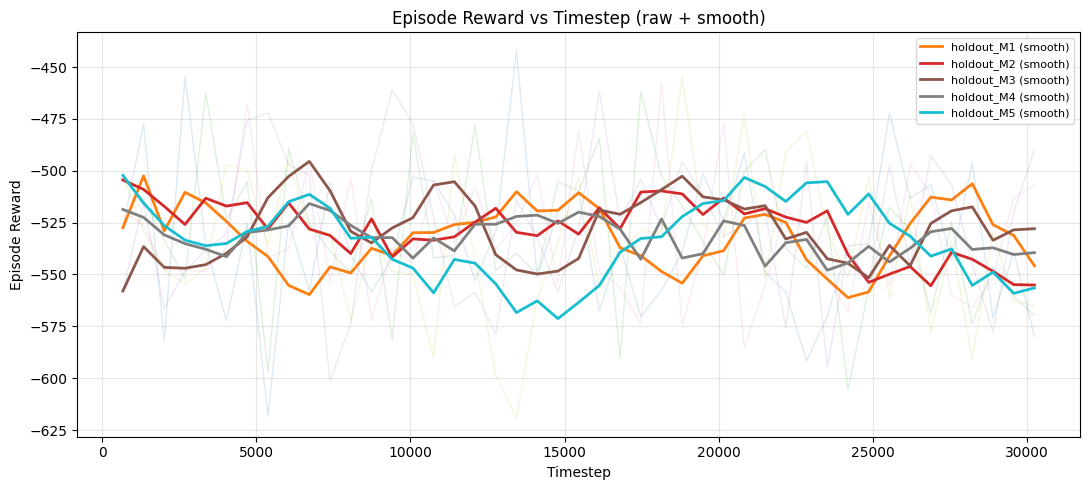

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


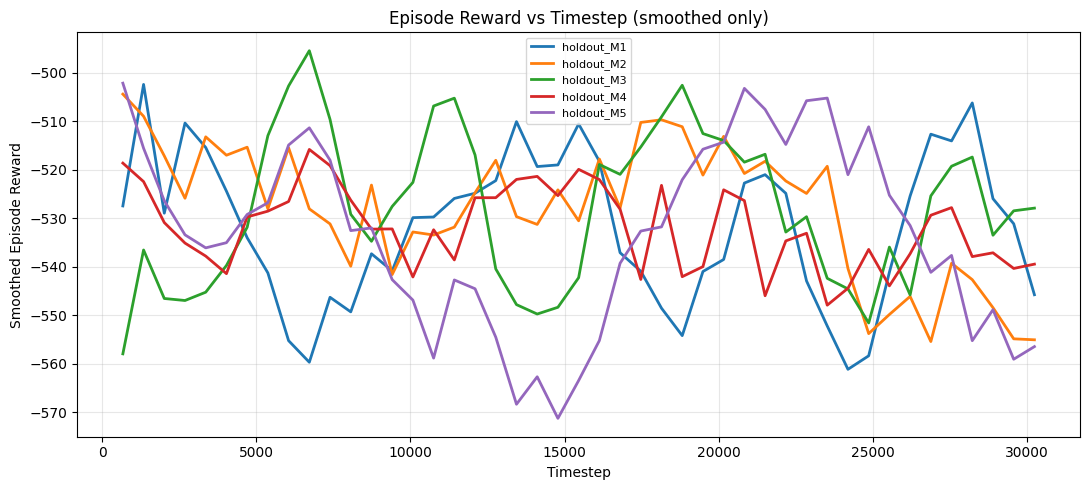

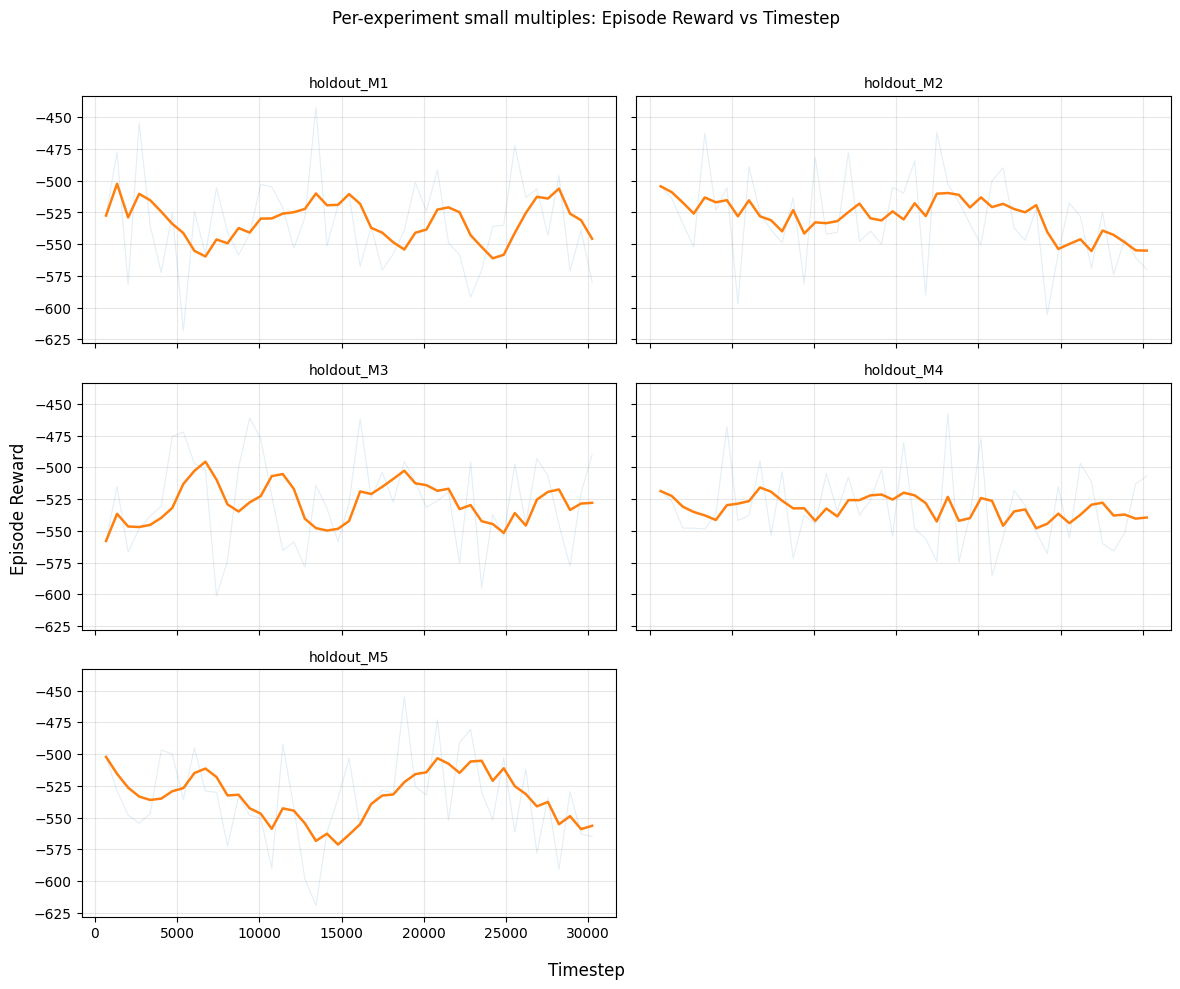

,experiment,timestep,episode_reward,episode_length,episode_reward_smooth
215,holdout_M5,24192,-551.848808,168.0,-521.041109
216,holdout_M5,24864,-502.896996,168.0,-511.168892
217,holdout_M5,25536,-561.388916,168.0,-525.283432
218,holdout_M5,26208,-511.794067,168.0,-531.521770
219,holdout_M5,26880,-577.938599,168.0,-541.173477
220,holdout_M5,27552,-534.422440,168.0,-537.688203
221,holdout_M5,28224,-590.787857,168.0,-555.266376
222,holdout_M5,28896,-529.438225,168.0,-548.876237
223,holdout_M5,29568,-562.859146,168.0,-559.089253
224,holdout_M5,30240,-564.927574,168.0,-556.487048


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


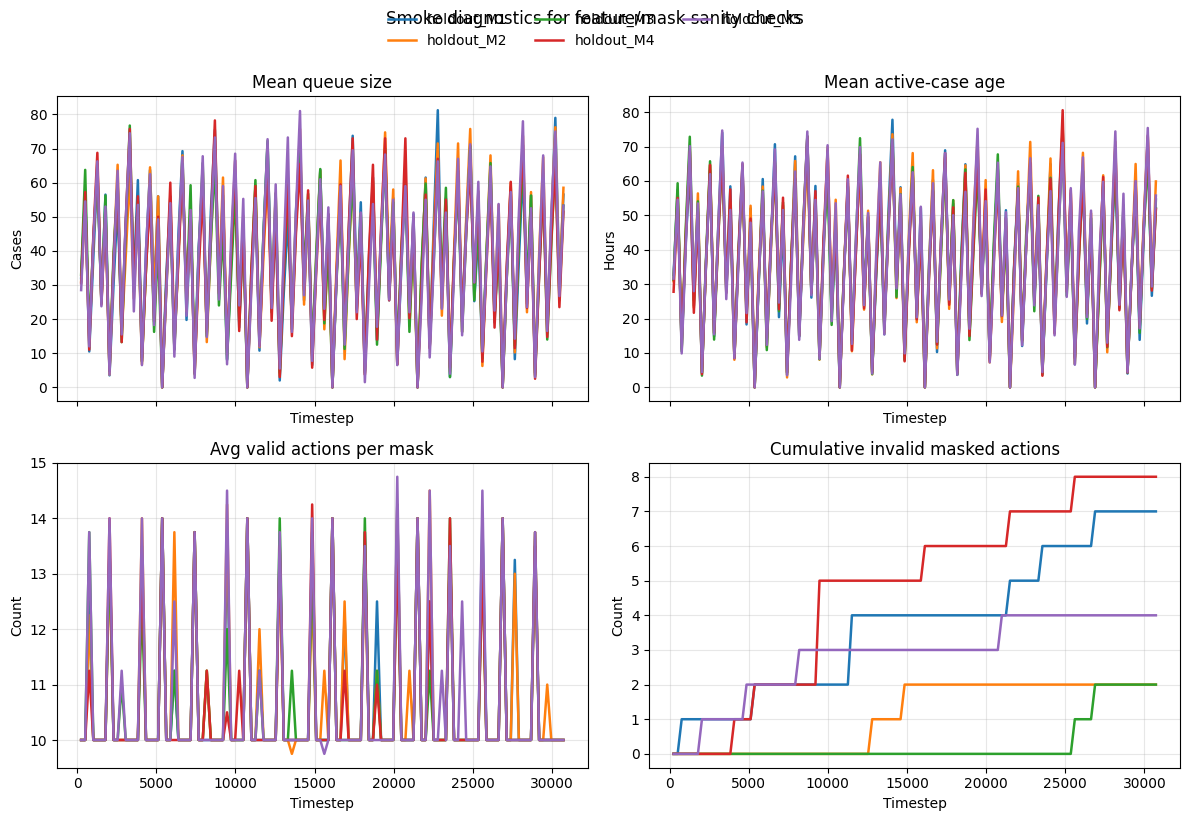

,experiment,timestep,mean_queue,mean_active_case_age,mean_workers,mean_hour,avg_valid_actions,min_valid_actions,max_valid_actions,invalid_mask_actions_this_sample,cumulative_invalid_mask_actions
590,holdout_M5,28416,23.50,23.956522,9.75,48.0,10.00,10.0,10.0,0,4
591,holdout_M5,28672,52.50,56.281555,9.75,112.0,10.00,10.0,10.0,0,4
592,holdout_M5,28928,3.00,4.416667,6.75,8.0,13.75,13.0,14.0,0,4
593,holdout_M5,29184,37.25,34.741497,9.75,72.0,10.00,10.0,10.0,0,4
594,holdout_M5,29440,68.00,59.966911,9.75,136.0,10.00,10.0,10.0,0,4
595,holdout_M5,29696,16.50,17.121212,9.75,32.0,10.00,10.0,10.0,0,4
596,holdout_M5,29952,51.00,46.470589,9.75,96.0,10.00,10.0,10.0,0,4
597,holdout_M5,30208,75.00,75.393936,9.75,160.0,10.00,10.0,10.0,0,4
598,holdout_M5,30464,26.75,29.304762,9.75,56.0,10.00,10.0,10.0,0,4
599,holdout_M5,30720,53.25,55.737091,9.75,120.0,10.00,10.0,10.0,0,4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
if 'episode_rewards_df' not in globals() or episode_rewards_df is None or len(episode_rewards_df) == 0:
    ep_path = OUTPUT_DIR / 'ppo_episode_rewards.csv'
    if ep_path.exists():
        episode_rewards_df = pd.read_csv(ep_path)
    else:
        episode_rewards_df = pd.DataFrame(columns=['experiment', 'timestep', 'episode_reward', 'episode_length'])

if 'smoke_diagnostics_df' not in globals() or smoke_diagnostics_df is None or len(smoke_diagnostics_df) == 0:
    diag_path = OUTPUT_DIR / 'ppo_smoke_diagnostics.csv'
    if diag_path.exists():
        smoke_diagnostics_df = pd.read_csv(diag_path)
    else:
        smoke_diagnostics_df = pd.DataFrame(columns=[
            'experiment', 'timestep', 'mean_queue', 'mean_active_case_age', 'mean_workers', 'mean_hour',
            'avg_valid_actions', 'min_valid_actions', 'max_valid_actions',
            'invalid_mask_actions_this_sample', 'cumulative_invalid_mask_actions',
        ])

if len(episode_rewards_df) == 0:
    print('No episode reward timeline available yet.')
else:
    plot_df = episode_rewards_df.sort_values(['experiment', 'timestep']).copy()
    # Aggregate multiple parallel-env episodes that land on the same timestep
    # before smoothing; this eliminates within-timestep aliasing (sawtooth noise).
    plot_df = (
        plot_df.groupby(['experiment', 'timestep'], sort=True)
        .agg(episode_reward=('episode_reward', 'mean'),
             episode_length=('episode_length', 'mean'))
        .reset_index()
    )
    # Window = 10 % of each experiment's own row count (not total df), at least 5.
    def _smooth_per_group(s):
        w = max(5, int(len(s) * 0.10))
        return s.rolling(window=w, min_periods=1).mean()
    plot_df['episode_reward_smooth'] = (
        plot_df.groupby('experiment')['episode_reward']
        .transform(_smooth_per_group)
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    for exp_name, g in plot_df.groupby('experiment'):
        ax.plot(g['timestep'], g['episode_reward'], alpha=0.15, linewidth=1)
        ax.plot(g['timestep'], g['episode_reward_smooth'], linewidth=2, label=f'{exp_name} (smooth)')
    ax.set_title('Episode Reward vs Timestep (raw + smooth)')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Episode Reward')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, ncol=1)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    for exp_name, g in plot_df.groupby('experiment'):
        ax.plot(g['timestep'], g['episode_reward_smooth'], linewidth=2, label=exp_name)
    ax.set_title('Episode Reward vs Timestep (smoothed only)')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Smoothed Episode Reward')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8, ncol=1)
    plt.tight_layout()
    plt.show()

    exp_names = list(plot_df['experiment'].dropna().unique())
    n_exp = len(exp_names)
    n_cols = 2
    n_rows = int(np.ceil(n_exp / n_cols)) if n_exp > 0 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, max(3.2 * n_rows, 4)), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

    for idx, exp_name in enumerate(exp_names):
        r, c = divmod(idx, n_cols)
        g = plot_df[plot_df['experiment'] == exp_name]
        axes[r, c].plot(g['timestep'], g['episode_reward'], alpha=0.12, linewidth=0.8)
        axes[r, c].plot(g['timestep'], g['episode_reward_smooth'], linewidth=1.8)
        axes[r, c].set_title(exp_name, fontsize=10)
        axes[r, c].grid(alpha=0.3)

    for idx in range(n_exp, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].axis('off')

    fig.suptitle('Per-experiment small multiples: Episode Reward vs Timestep', y=1.02)
    fig.supxlabel('Timestep')
    fig.supylabel('Episode Reward')
    plt.tight_layout()
    plt.show()

    display(plot_df.tail(10))

if len(smoke_diagnostics_df) == 0:
    print('No smoke diagnostics timeline available yet.')
else:
    diag_df = smoke_diagnostics_df.sort_values(['experiment', 'timestep']).copy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for exp_name, g in diag_df.groupby('experiment'):
        axes[0, 0].plot(g['timestep'], g['mean_queue'], linewidth=1.8, label=exp_name)
        axes[0, 1].plot(g['timestep'], g['mean_active_case_age'], linewidth=1.8, label=exp_name)
        axes[1, 0].plot(g['timestep'], g['avg_valid_actions'], linewidth=1.8, label=exp_name)
        axes[1, 1].plot(g['timestep'], g['cumulative_invalid_mask_actions'], linewidth=1.8, label=exp_name)

    axes[0, 0].set_title('Mean queue size')
    axes[0, 1].set_title('Mean active-case age')
    axes[1, 0].set_title('Avg valid actions per mask')
    axes[1, 1].set_title('Cumulative invalid masked actions')

    for ax in axes.flat:
        ax.set_xlabel('Timestep')
        ax.grid(alpha=0.3)

    axes[0, 0].set_ylabel('Cases')
    axes[0, 1].set_ylabel('Hours')
    axes[1, 0].set_ylabel('Count')
    axes[1, 1].set_ylabel('Count')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if len(handles) > 0:
        fig.legend(handles, labels, loc='upper center', ncol=min(3, len(labels)), frameon=False)
    fig.suptitle('Smoke diagnostics for feature/mask sanity checks', y=1.02)
    plt.tight_layout()
    plt.show()

    display(diag_df.tail(10))